# BCH111 — Stimulus-Stability History (mapping)

**Purpose.** Map the stimulus-delivery stability of subject **BCH111** (chronic
evoked recording at 0.5 Hz) across its `(stim site, record site)` configurations,
gated on access resistance (Rₐ), with per-trial artifact metrics (polarity,
amplitude, shape), seizure counts, and distributional comparisons.

**This notebook is mapping only** — it makes *no* experimental recommendations.
Null / ambiguous / collinear results are reported plainly.

### Wiring convention (operator-confirmed)
In a channel `BCH111<AREA>` the **named** `<AREA>` is the **RECORD** site; the
**unnamed** site is the **STIM** target. So `BCH111SLM` ⇒ *(stim = SR, record = SLM)*.

> ⚠️ The codebase's `stim_map` / `impedance_refresh` attribute the injected current
> — and thus the stored `access_r_kohm` — to the *named* electrode (the opposite
> wiring). We use that positional rule only to *detect* the named electrode and
> swaps; the stored 'Rₐ' here is therefore the ΔV/ΔI measured on the **record**
> channel while the other site is stimulated. It is used purely as a stable,
> monotonic gating signal for interface stability.

Everything is read-only. Heavy trace reads use a windowed HDF5 slice (~170× faster
than reading the full ±500 ms trace).

## 0. Setup

In [1]:
import os, sys, datetime as D
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

# repo root on path (run from notebooks/ or repo root)
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..')) \
    if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
if ROOT not in sys.path: sys.path.insert(0, ROOT)
os.chdir(ROOT)   # so relative data/ paths resolve to the repo root

from src.dashboard.data_helpers import load_config
from src.db.store import Store
from src.preictal.isi import parse_chunk_datetime, scored_seizures
from src.utils import evoked_output as eo
from src.chronic_stability import (ra_flatrun as fr, config_timeline as ct,
                                   metrics as M, compare as C, render, report)

ANIMAL = 'BCH111'
cfg = load_config()
store = Store(cfg['database']['path'])
EVOKED_DIR = cfg['chronic_evoked']['evoked_output_dir']
OUT = os.path.join('data', 'derivatives', 'chronic_stability', ANIMAL)
os.makedirs(OUT, exist_ok=True)
ISO = lambda e: D.datetime.fromtimestamp(float(e)).strftime('%Y-%m-%d %H:%M')
print('DB   :', cfg['database']['path'])
print('EVOKED:', EVOKED_DIR)

DB   : D:/code/qc_monitor/data/monitor.db
EVOKED: D:/code/Stimulation-Telemetry-Modulation-NeuroEngineering-Toolkit/daqSignalGenerator/evokedOutput


## 1. Stage 0 — data probe

Ground the analysis: which Rₐ series exist, how many evoked files, how many seizures.

In [2]:
ser = store.impedance_series_by_channel()
ra_keys = sorted(k for k in ser if k[0] == ANIMAL)
for k in ra_keys:
    rows = ser[k]
    print(f'{k[1]:>10}: {len(rows):4d} Rₐ pts  {rows[0]["chunk_datetime"]} .. {rows[-1]["chunk_datetime"]}')
files = sorted(f for f in eo.list_evoked_files(EVOKED_DIR) if ANIMAL in os.path.basename(f))
seiz = scored_seizures(store, ANIMAL)
sz_ep = np.array([s.onset_epoch for s in seiz], float)
print(f'evoked files: {len(files)}   seizures: {len(seiz)}  '
      f'({ISO(sz_ep.min())} .. {ISO(sz_ep.max())})')

 BCH111SLM:  920 Rₐ pts  2026_07_20__14_10_44 .. 2026_08_31__14_36_34
  BCH111SR:  164 Rₐ pts  2026_07_13__15_34_42 .. 2026_07_20__12_52_11
evoked files: 1368   seizures: 52  (2026-07-02 17:26 .. 2026-08-17 02:25)


## 2. Stage 1 — Rₐ flat-run detection (the stable window)

A period is **stable** when Rₐ is flat. We detect the *longest contiguous flat run*
programmatically. **Criterion:** on a centered 24 h rolling window we require both the
rolling **drift** (|slope|·window) and the rolling **dispersion** (robust SD) to sit
within a few multiples of the series' **noise floor** — the irreducible
sample-to-sample wiggle `nf = 1.4826·MAD(Δr)/√2`.

Why the noise floor and not %-of-median: BCH111's Rₐ is sub-kΩ and its flattest stretch
dips to ~0.13 kΩ; normalising a 0.012 kΩ wiggle by that tiny median would make the
*flattest* window look noisier than a higher-magnitude drifting one. Dropouts are absent
rows (NULL Rₐ is dropped upstream), so gaps come from timestamp deltas; a gap > 6 h breaks
a run. A **lone** spike is flagged but tolerated (stats are computed with spikes excluded);
**two adjacent** spikes break the run.

In [3]:
# gating series = the record electrode whose Rₐ trend the operator eyeballed (SLM)
def ra_series(channel):
    rows = ser.get((ANIMAL, channel), [])
    te = np.array([parse_chunk_datetime(r['chunk_datetime']).timestamp() for r in rows], float)
    r  = np.array([r['access_r_kohm'] for r in rows], float)
    return te, r

GATE_CH = 'BCH111SLM'
te, r = ra_series(GATE_CH)
th = (te - te[0]) / 3600.0
run = fr.detect_longest_flat_run(th, r, te, win_h=24, gap_tol_h=6, disp_k=4.0, slope_k=6.0)
print('STABLE WINDOW:', ISO(run['epoch_start']), '->', ISO(run['epoch_end']))
print(f"  duration {run['duration_h']:.1f} h · {run['n_samples']} Rₐ pts · "
      f"trial-index {run['idx_start']}–{run['idx_end']} · median Rₐ "
      f"{run['median_ra_kohm']:.3f} kΩ · robust CV {run['robust_cv_pct']:.1f}%")
print(f"  noise floor {run['flat_mask']['noise_floor']:.4f} kΩ · "
      f"{len(run['flagged_spikes_in_run'])} lone spike(s) tolerated · "
      f"{run['n_gaps_tolerated']} gap(s), max {run['max_gap_h']:.1f} h")

STABLE WINDOW: 2026-07-22 11:21 -> 2026-07-29 08:56
  duration 165.6 h · 163 Rₐ pts · trial-index 45–207 · median Rₐ 0.138 kΩ · robust CV 17.9%
  noise floor 0.0175 kΩ · 1 lone spike(s) tolerated · 0 gap(s), max 1.3 h


**Validate against the eyeballed window (~Jul 21–31)** and render the trend.

eyeball validation: {'iou': np.float64(0.69), 'pct_eye_covered': np.float64(68.99), 'pct_det_covered': np.float64(100.0), 'delta_start_h': np.float64(35.36), 'delta_end_h': np.float64(-39.06), 'verdict_pass': False}
seizures inside the stable window: 4  (expectation was ≥6 — an OUTCOME, not a criterion)


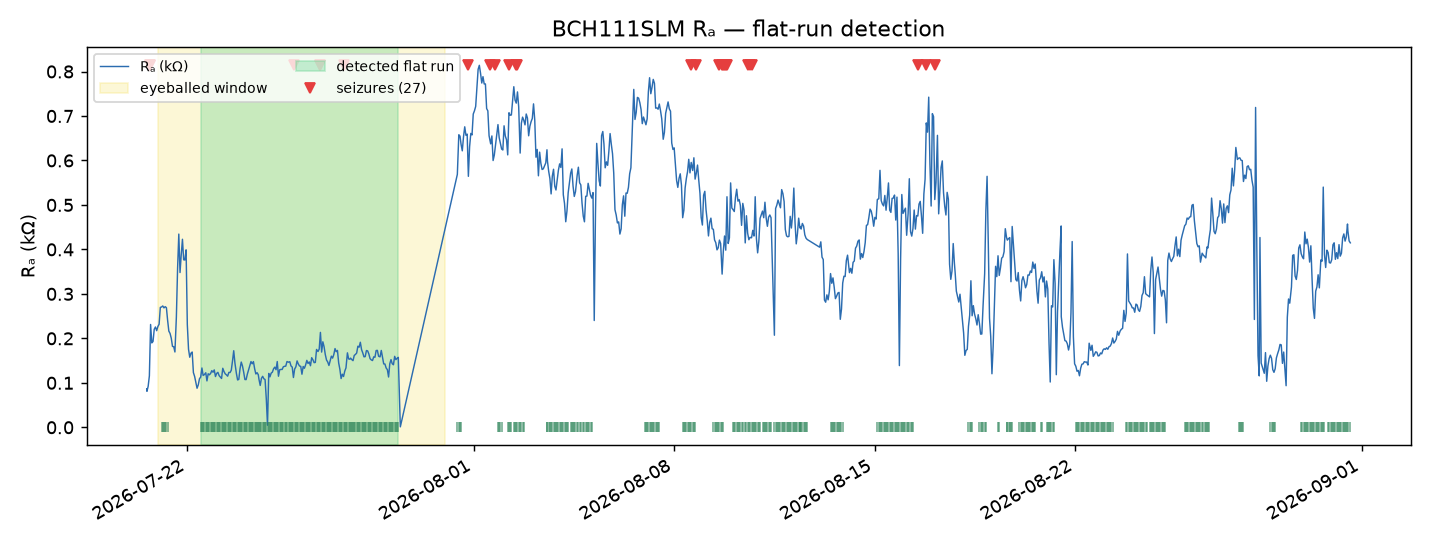

In [4]:
EYE = (D.datetime(2026,7,21).timestamp(), D.datetime(2026,7,31).timestamp())
val = fr.validate_against_window(run, te, *EYE)
print('eyeball validation:', {k: (round(v,2) if isinstance(v,float) else v) for k,v in val.items()})
n_sz = int(((sz_ep>=run['epoch_start'])&(sz_ep<=run['epoch_end'])).sum())
print(f'seizures inside the stable window: {n_sz}  (expectation was ≥6 — an OUTCOME, not a criterion)')
png = render.ra_flatrun_fig(te, r, run, *EYE, sz_ep, os.path.join(OUT, f'{ANIMAL}_flatrun_validation.png'),
                            title=f'{GATE_CH} Rₐ — flat-run detection')
display(Image(png))

**Sensitivity sweep** — show the detected window is robust to the threshold choice, not tuned.

all parameter sets found a run: True


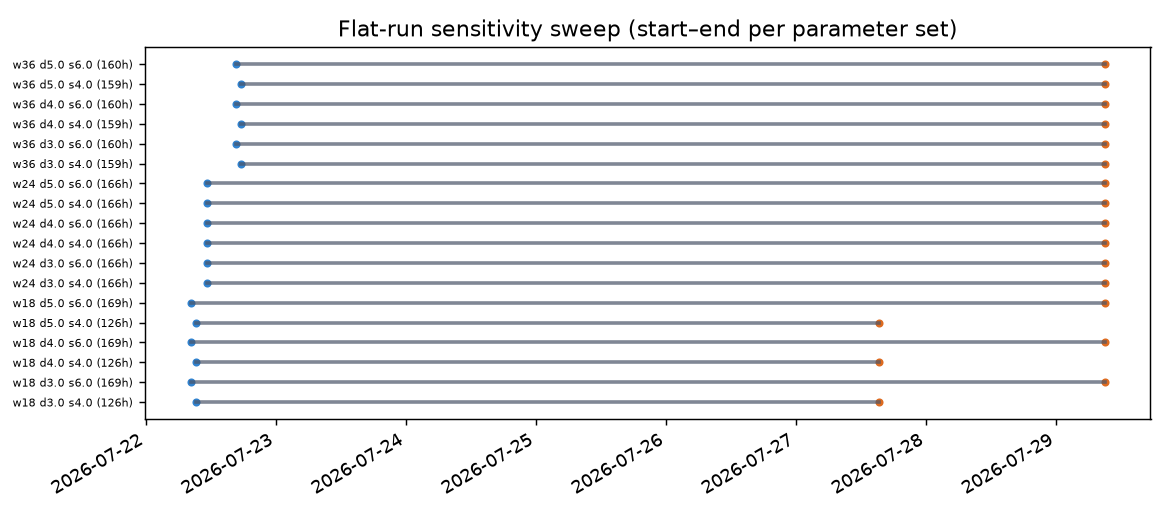

,win_h,disp_k,slope_k,start,end,dur_h
0,18,3,4,2026-07-22 09:19,2026-07-27 15:18,126.0
1,18,3,6,2026-07-22 08:18,2026-07-29 08:56,169.0
2,18,4,4,2026-07-22 09:19,2026-07-27 15:18,126.0
3,18,4,6,2026-07-22 08:18,2026-07-29 08:56,169.0
4,18,5,4,2026-07-22 09:19,2026-07-27 15:18,126.0
5,18,5,6,2026-07-22 08:18,2026-07-29 08:56,169.0
6,24,3,4,2026-07-22 11:21,2026-07-29 08:56,166.0
7,24,3,6,2026-07-22 11:21,2026-07-29 08:56,166.0
8,24,4,4,2026-07-22 11:21,2026-07-29 08:56,166.0
9,24,4,6,2026-07-22 11:21,2026-07-29 08:56,166.0


In [5]:
grid = [dict(win_h=w, disp_k=d, slope_k=s) for w in (18,24,36) for d in (3,4,5) for s in (4,6)]
sw = fr.sensitivity_sweep(th, r, te, grid)
swdf = pd.DataFrame([{**g, 'start': ISO(g['epoch_start']), 'end': ISO(g['epoch_end']),
                      'dur_h': round(g['duration_h'],0)} for g in sw if g['found']])
print('all parameter sets found a run:', all(g['found'] for g in sw))
png = render.sensitivity_fig(sw, os.path.join(OUT, f'{ANIMAL}_sensitivity.png')); display(Image(png))
swdf[['win_h','disp_k','slope_k','start','end','dur_h']].head(20)

## 3. Stage 2 — configuration timeline & the swap

A **configuration** = `(stim site, record site)`. We find BCH111's named (record)
electrode per session via the positional stimCopy rule, apply the operator's convention
to label `(stim, record)`, and merge consecutive same-record-site sessions into config
intervals. A change of record site = a **configuration swap**; a change of stim charge at
the same site is a *within-config* event (reported separately).

In [6]:
sessions = ct.bch111_sessions(store, ANIMAL)
intervals = ct.config_intervals(sessions)
events = ct.detect_config_events(sessions)
for iv in intervals:
    end = 'ongoing' if not np.isfinite(iv['end_epoch']) else ISO(iv['end_epoch'])
    print(f"{iv['config_label']:<22} {ISO(iv['start_epoch'])} .. {end:<16} "
          f"modal charge {iv['modal_charge_nC']} nC · {iv['n_sessions']} sessions")
print()
for e in events:
    print(f"{e['event_type']:<14} @ {ISO(e['at_epoch'])}   {e['from_config']} -> {e['to_config']}")
swap = next((e for e in events if e['event_type']=='site_swap'), None)
if swap:
    p = swap['provenance']
    print('\nSWAP provenance:', p['table']+'.'+p['field'],
          '| before:', os.path.basename(p['session_dir_before']),
          '| after:', os.path.basename(p['session_dir_after']))

(stim=SLM, rec=SR)     2026-07-13 15:19 .. 2026-07-20 14:05 modal charge 2.0 nC · 5 sessions
(stim=SR, rec=SLM)     2026-07-20 14:05 .. ongoing          modal charge 5.0 nC · 8 sessions

charge_change  @ 2026-07-13 15:34   (stim=SLM, rec=SR, 5.0nC) -> (stim=SLM, rec=SR, 2.0nC)
charge_change  @ 2026-07-13 15:36   (stim=SLM, rec=SR, 2.0nC) -> (stim=SLM, rec=SR, 1.0nC)
charge_change  @ 2026-07-13 15:38   (stim=SLM, rec=SR, 1.0nC) -> (stim=SLM, rec=SR, 2.0nC)
site_swap      @ 2026-07-20 14:05   (stim=SLM, rec=SR, 2.0nC) -> (stim=SR, rec=SLM, 2.0nC)
charge_change  @ 2026-07-20 14:10   (stim=SR, rec=SLM, 2.0nC) -> (stim=SR, rec=SLM, 5.0nC)
charge_change  @ 2026-08-11 10:51   (stim=SR, rec=SLM, 5.0nC) -> (stim=SR, rec=SLM, 0.0nC)

SWAP provenance: session_config.channel_names | before: chronicStim-5nC-2nC__stimCopy_BCH110SLM_stimCopy_BCH111SR_BCH061SLM_BCH114SLM_ | after: chronicStim-5nC-2nC__stimCopy_BCH110SLM_stimCopy_BCH111SLM_BCH061SLM_BCH114SLM_


## 4. Stages 3–5 — per-trial metrics, distributions, report

The remaining stages read every trial's artifact window (**[-1, 2] ms** on the LFP record
channel), build a **fixed template** = median artifact over the stable window, express the
whole record as deviation from it (correlation + span-normalised RMSE), compute polarity
and peak-to-trough amplitude, count seizures per config, and run the distributional
comparisons with **dependence-aware block-bootstrap** CIs.

`report.run(...)` executes all of this with progress and writes every CSV/PNG plus a
markdown report to `data/derivatives/chronic_stability/BCH111/`. **This reads ~1.4k files
once (a few minutes).**

In [7]:
ctx = report.run(store, ANIMAL, EVOKED_DIR, OUT,
                 eye_lo=EYE[0], eye_hi=EYE[1],
                 flat_params=dict(win_h=24, gap_tol_h=6, disp_k=4.0, slope_k=6.0),
                 n_boot=2000)
print('trials:', ctx['metrics']['epoch'].size, '| configs:', len(ctx['intervals']))

[chronic_stability] enumerating configurations for BCH111 ...


[chronic_stability] 2 configuration(s); detecting stable Rₐ run ...


[chronic_stability] 1368 evoked files; building template over stable window ...


  trials: 1/168 files  1360/min  ETA 0.1 min


  trials: 50/168 files  5791/min  ETA 0.0 min


...

  trials: 1300/1368 files  5840/min  ETA 0.0 min


  trials: 1350/1368 files  5907/min  ETA 0.0 min


  trials: 1368/1368 files  5929/min  ETA 0.0 min


[chronic_stability] done -> data\derivatives\chronic_stability\BCH111


trials: 2406144 | configs: 2


### 4a. Per-configuration timeline table

In [8]:
pc = pd.DataFrame(ctx['per_config'])
pc['start'] = pc['start_epoch'].map(ISO)
pc[['config_label','stim_site','record_site','start','duration_h','n_trials',
    'n_seizures','modal_charge_nC','ra_median','amp_median','corr_median',
    'nrmse_median','polarity_switch']]

,config_label,stim_site,record_site,start,duration_h,n_trials,n_seizures,modal_charge_nC,ra_median,amp_median,corr_median,nrmse_median,polarity_switch
0,"(stim=SLM, rec=SR)",SLM,SR,2026-07-13 15:19,166.767778,290107,12,2.0,0.308232,6.744506,-0.994286,0.204888,9272
1,"(stim=SR, rec=SLM)",SR,SLM,2026-07-20 14:05,1009.514167,1655622,27,5.0,0.387374,8.071264,0.425714,0.129940,9958


### 4b. Per-trial metrics + Rₐ over time (config bands, stable window, seizure rug)

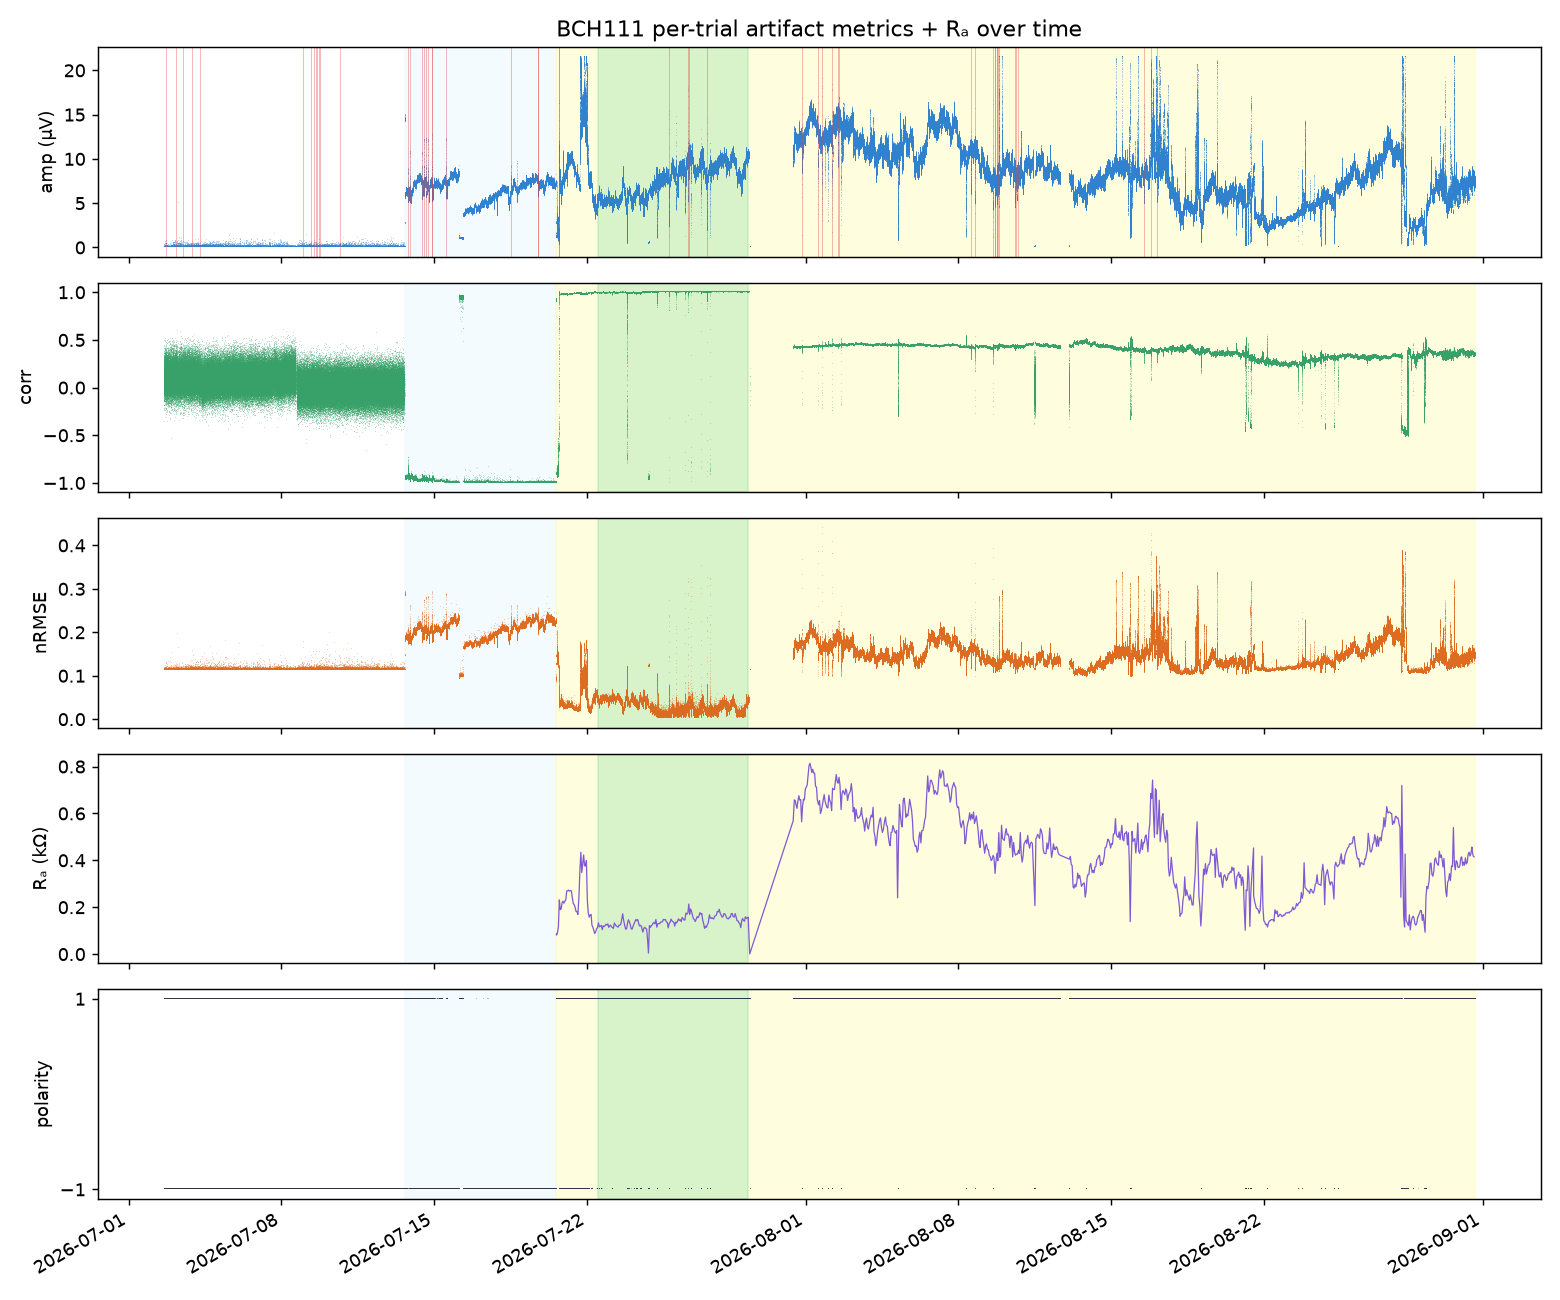

In [9]:
display(Image(os.path.join(OUT, f'{ANIMAL}_metric_timeseries.png')))

### 4c. Distributions — stable window vs its own config vs the other config

Distributions (ECDF + violin), not point estimates. Note the **cross-config shape caveat**:
the two configs record from *different* electrodes, so correlation/RMSE across configs
conflate stimulus-delivery change with electrode identity — amplitude / polarity / Rₐ are the
cleaner cross-config comparators.

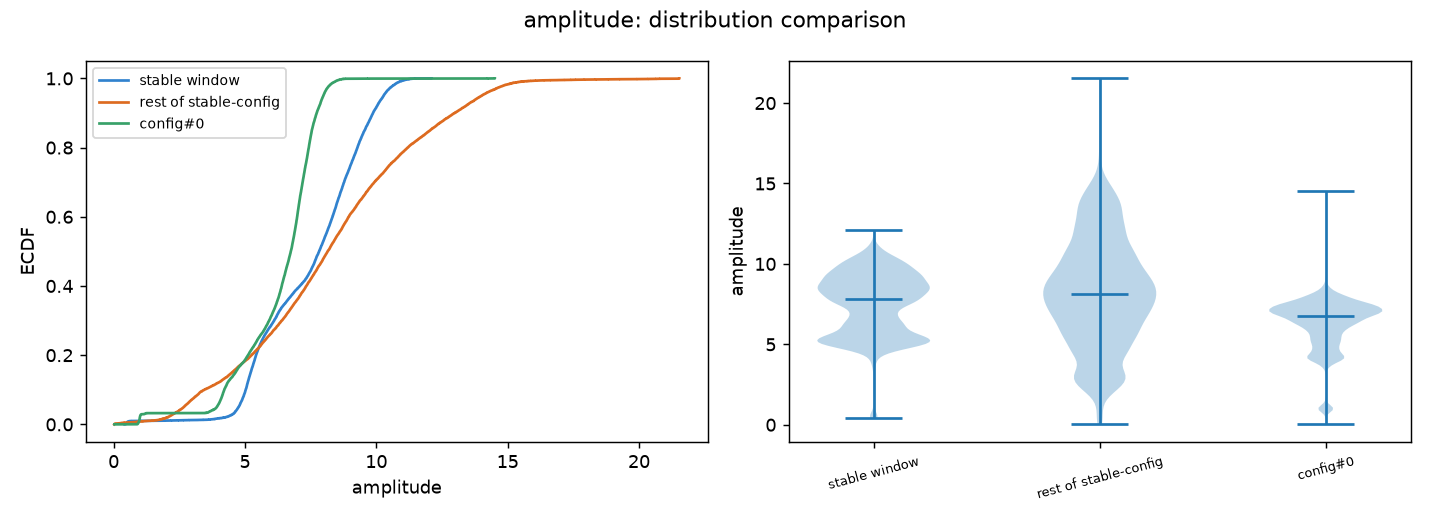

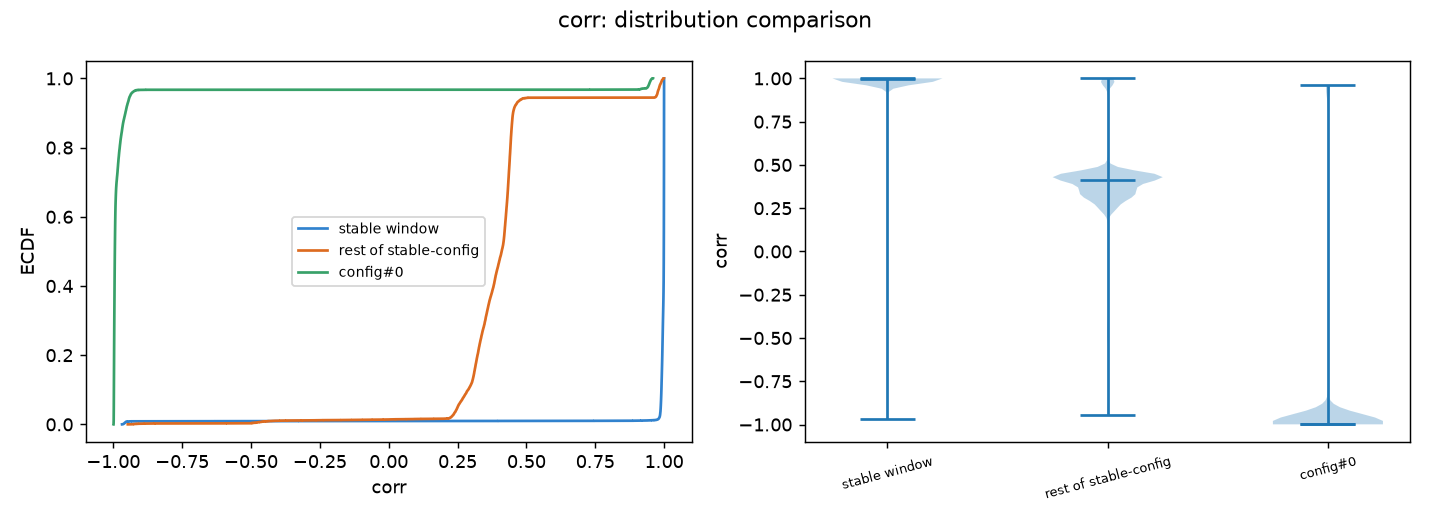

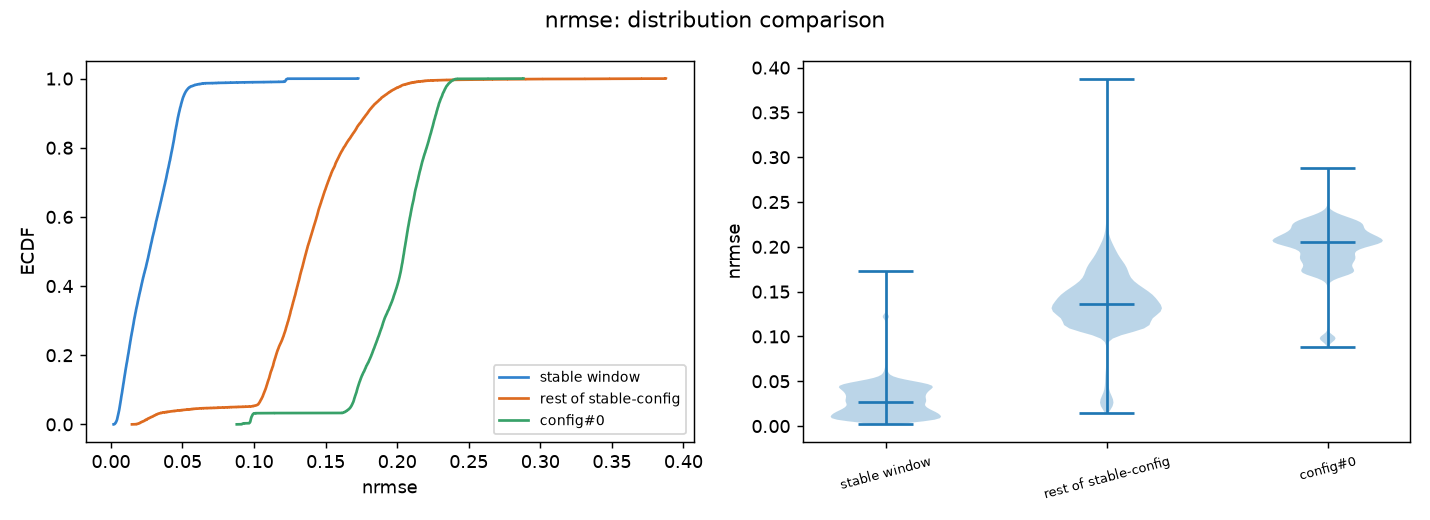

,name,n_a,n_b,median_a,median_b,ks_p,mwu_p,cliffs_delta,median_diff,ci_lo,ci_hi
0,amplitude: stable-window vs rest-of-config,288440,1367182,7.8227,8.1482,0.0,0.0,-0.1253,-0.3254,-0.6943,-0.0045
1,amplitude: stable-config vs config#0,1655622,290107,8.0713,6.7445,0.0,0.0,0.3786,1.3268,1.1211,1.5489
2,amplitude: stable-window vs config#0,288440,290107,7.8227,6.7445,0.0,0.0,0.3711,1.0782,0.7406,1.3803
3,corr: stable-window vs rest-of-config,288440,1367182,0.9989,0.4101,0.0,0.0,0.9750,0.5887,0.5822,0.5962
4,corr: stable-config vs config#0,1655622,290107,0.4257,-0.9943,0.0,0.0,0.9489,1.4200,1.4170,1.4228
5,corr: stable-window vs config#0,288440,290107,0.9989,-0.9943,0.0,0.0,0.9980,1.9932,1.9925,1.9938
6,nrmse: stable-window vs rest-of-config,288440,1367182,0.0269,0.1366,0.0,0.0,-0.9572,-0.1097,-0.1129,-0.1067
7,nrmse: stable-config vs config#0,1655622,290107,0.1299,0.2049,0.0,0.0,-0.8838,-0.0749,-0.0775,-0.0724
8,nrmse: stable-window vs config#0,288440,290107,0.0269,0.2049,0.0,0.0,-0.9990,-0.1780,-0.1815,-0.1748


In [10]:
for key in ('amplitude','corr','nrmse'):
    display(Image(os.path.join(OUT, f'{ANIMAL}_dist_{key}.png')))
cmp = pd.DataFrame([c for c in ctx['comparisons'] if 'median_a' in c])
cmp[['name','n_a','n_b','median_a','median_b','ks_p','mwu_p','cliffs_delta',
     'median_diff','ci_lo','ci_hi']].round(4)

### 4d. Collinearity — configuration age vs stability

Configuration age and stability are typically confounded (an older config has drifted
further). We **report** this, not adjust it: the stable window's age band vs the config's
full age range, Spearman ρ(age, metric) per config, and age-stratified ECDFs.

stable window occupies config age 45-211 h of the config's 0-1010 h span (16% of its age)
(stim=SLM, rec=SR) {'amplitude': 0.068, 'corr': -0.716, 'nrmse': 0.401}
(stim=SR, rec=SLM) {'amplitude': -0.372, 'corr': -0.864, 'nrmse': 0.342}


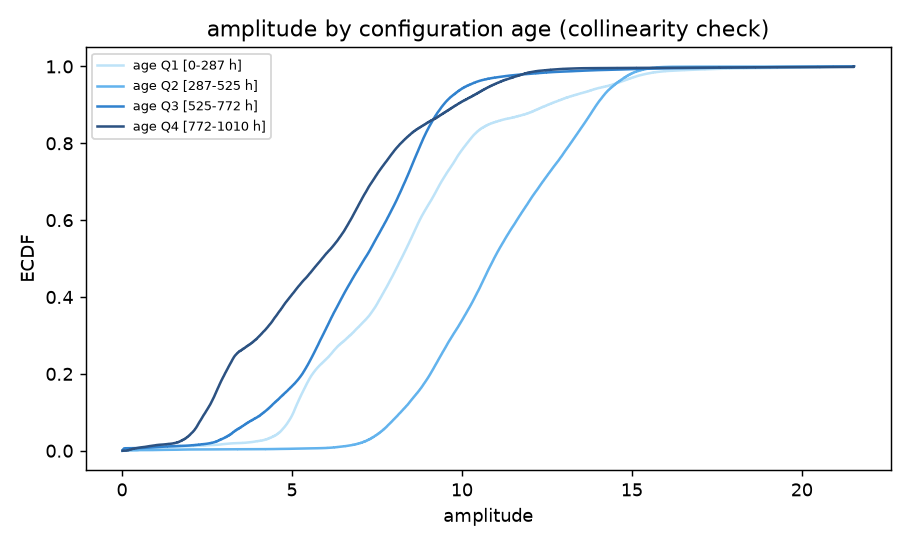

In [11]:
b = ctx['collinearity']['stable_age_band']
print(f"stable window occupies config age {b['stable_age_lo_h']:.0f}-{b['stable_age_hi_h']:.0f} h "
      f"of the config's {b['config_age_lo_h']:.0f}-{b['config_age_hi_h']:.0f} h span "
      f"({100*b['stable_frac_of_config_age']:.0f}% of its age)")
for lab, d in ctx['collinearity']['per_config'].items():
    print(lab, {k: round(d[k]['rho'],3) for k in ('amplitude','corr','nrmse') if k in d})
display(Image(os.path.join(OUT, f'{ANIMAL}_age_amplitude.png')))

## 5. Written report

The full mapping narrative (config timeline, swap provenance, stable window + validation,
distributions, collinearity, caveats) is written to `BCH111_stability_report.md` alongside
the CSV/PNG artifacts. Rendered here for convenience.

In [12]:
from IPython.display import Markdown
with open(os.path.join(OUT, f'{ANIMAL}_stability_report.md'), encoding='utf-8') as f:
    display(Markdown(f.read()))

# BCH111 — Stimulus-Stability History (mapping)

_Generated 2026-08-31 16:07 · read-only · mapping only, no experimental recommendations._

Convention: the NAMED electrode in `BCH111<AREA>` is the RECORD site; the unnamed site is the STIM target. ⚠️ The codebase's stim_map / impedance_refresh attribute the current (and thus the stored `access_r_kohm`) to that named electrode, i.e. the opposite wiring; the stored 'Rₐ' here is therefore the ΔV/ΔI on the RECORD channel while the other site is stimulated. It is used only as a stable, monotonic gating signal for interface stability.

## 1. Configuration timeline

| config | stim | rec | start | end | dur (h) | trials | seizures | charge (nC) | Rₐ med (kΩ) | amp med | corr med | nRMSE med | pol switches |
|---|---|---|---|---|--:|--:|--:|--:|--:|--:|--:|--:|--:|
| (stim=SLM, rec=SR) | SLM | SR | 2026-07-13 15:19 | 2026-07-20 14:05 | 167 | 290107 | 12 | 2.0 | 0.308 | 6.74 | -0.994 | 0.205 | 9272 |
| (stim=SR, rec=SLM) | SR | SLM | 2026-07-20 14:05 | ongoing | 1010 | 1655622 | 27 | 5.0 | 0.387 | 8.07 | 0.426 | 0.130 | 9958 |

Total seizures for BCH111 (record-wide): 52.

## 2. Configuration swap(s) & within-config events

- **SITE SWAP @ 2026-07-20 14:05**: (stim=SLM, rec=SR, 2.0nC) → (stim=SR, rec=SLM, 2.0nC). Provenance: `session_config.channel_names`, session before `chronicStim-5nC-2nC__stimCopy_BCH110SLM_stimCopy_BCH111SR_BCH061SLM_BCH114SLM_` → after `chronicStim-5nC-2nC__stimCopy_BCH110SLM_stimCopy_BCH111SLM_BCH061SLM_BCH114SLM_` (report ch 2, fp mapped).

Within-config charge changes (NOT configuration swaps): 2026-07-13 15:34 (stim=SLM, rec=SR, 5.0nC)→(stim=SLM, rec=SR, 2.0nC); 2026-07-13 15:36 (stim=SLM, rec=SR, 2.0nC)→(stim=SLM, rec=SR, 1.0nC); 2026-07-13 15:38 (stim=SLM, rec=SR, 1.0nC)→(stim=SLM, rec=SR, 2.0nC); 2026-07-20 14:10 (stim=SR, rec=SLM, 2.0nC)→(stim=SR, rec=SLM, 5.0nC); 2026-08-11 10:51 (stim=SR, rec=SLM, 5.0nC)→(stim=SR, rec=SLM, 0.0nC)

## 3. Stable window (longest programmatic flat Rₐ run)

Detected on the **SLM** Rₐ trend (config (stim=SR, rec=SLM)).

- **Boundaries:** 2026-07-22 11:21 → 2026-07-29 08:56 (trial-index 45–207 on the Rₐ series).
- **Duration:** 165.6 h · 163 Rₐ points · median Rₐ 0.138 kΩ · robust CV 17.9%.
- **Artifacts:** 1 lone spike(s) tolerated; 0 gap(s) tolerated, max gap 1.3 h (a gap > tolerance would break the run).
- **Seizures inside the window:** **4** (expectation was ≥6; this is an OUTCOME, not a selection criterion).
- **Position vs swap:** the window starts 45.3 h after the configuration it lives in began.

- **Eyeball validation** (vs 2026-07-21 00:00–2026-07-31 00:00): IoU 0.69, 100% of the detected window inside the eyeball, 69% of the eyeball covered; boundary Δstart +35 h, Δend -39 h. Tight-agreement verdict: partial (detected core is narrower than the hand-drawn span).

## 4. Distributions (not point estimates)

| comparison | n(a) | n(b) | med(a) | med(b) | KS p | MWU p | Cliff's δ | Δmedian [95% block-CI] |
|---|--:|--:|--:|--:|--:|--:|--:|---|
| amplitude: stable-window vs rest-of-config | 288440 | 1367182 | 7.823 | 8.148 | 0.0e+00 | 0.0e+00 | -0.125 | -0.325 [-0.694, -0.005] |
| amplitude: stable-config vs config#0 | 1655622 | 290107 | 8.071 | 6.745 | 0.0e+00 | 0.0e+00 | +0.379 | +1.327 [+1.121, +1.549] |
| amplitude: stable-window vs config#0 | 288440 | 290107 | 7.823 | 6.745 | 0.0e+00 | 0.0e+00 | +0.371 | +1.078 [+0.741, +1.380] |
| corr: stable-window vs rest-of-config | 288440 | 1367182 | 0.999 | 0.410 | 0.0e+00 | 0.0e+00 | +0.975 | +0.589 [+0.582, +0.596] |
| corr: stable-config vs config#0 | 1655622 | 290107 | 0.426 | -0.994 | 0.0e+00 | 0.0e+00 | +0.949 | +1.420 [+1.417, +1.423] |
| corr: stable-window vs config#0 | 288440 | 290107 | 0.999 | -0.994 | 0.0e+00 | 0.0e+00 | +0.998 | +1.993 [+1.993, +1.994] |
| nrmse: stable-window vs rest-of-config | 288440 | 1367182 | 0.027 | 0.137 | 0.0e+00 | 0.0e+00 | -0.957 | -0.110 [-0.113, -0.107] |
| nrmse: stable-config vs config#0 | 1655622 | 290107 | 0.130 | 0.205 | 0.0e+00 | 0.0e+00 | -0.884 | -0.075 [-0.077, -0.072] |
| nrmse: stable-window vs config#0 | 288440 | 290107 | 0.027 | 0.205 | 0.0e+00 | 0.0e+00 | -0.999 | -0.178 [-0.182, -0.175] |

Polarity (polarity: stable-config vs other): frac(+) 0.971 vs 0.159, Fisher p 0.0e+00.

_CIs use a dependence-aware moving-block bootstrap (consecutive trials are autocorrelated; an iid bootstrap would understate the CI)._

## 5. Configuration age vs stability (collinearity — reported, not adjusted)

The stable window occupies configuration age 45–211 h, out of the config's full 0–1010 h span (16% of its age range). Stability and age are therefore confounded — a stable-vs-full difference is read JOINTLY with age.

Spearman ρ(config age, metric) per configuration:

- (stim=SLM, rec=SR): amplitude ρ=+0.07 (p=1.6e-295), corr ρ=-0.72 (p=0.0e+00), nrmse ρ=+0.40 (p=0.0e+00)
- (stim=SR, rec=SLM): amplitude ρ=-0.37 (p=0.0e+00), corr ρ=-0.86 (p=0.0e+00), nrmse ρ=+0.34 (p=0.0e+00)

## 6. Caveats & null/ambiguous results

- **Cross-config shape:** the two configurations record from DIFFERENT electrodes, so corr/nRMSE of the other config vs a stable-config template conflate stimulus-delivery change with record-electrode identity. Amplitude / polarity / Rₐ are the cleaner cross-config comparators.
- **Age–stability collinearity** is intrinsic (see §5) and is not adjusted away.
- **Seizure expectation:** the stable window holds 4 seizures, below the anticipated ≥6 — reported as an outcome.
- **Timestamps** are naive local wall-clock (evoked filenames and DB chunk_datetime share the same basis; no UTC layer).


---
### Artifacts written to `data/derivatives/chronic_stability/BCH111/`
- `BCH111_per_trial_metrics.csv.gz` — every trial: epoch, channel, config, in-stable-window, polarity, amplitude, corr, nRMSE
- `BCH111_config_timeline.csv`, `BCH111_config_events.json` — configs + swap/charge events with provenance
- `BCH111_comparisons.csv` — all distributional comparisons
- `*_flatrun_validation.png`, `*_sensitivity.png`, `*_metric_timeseries.png`, `*_dist_*.png`, `*_age_amplitude.png`
- `BCH111_stability_report.md` — the mapping narrative